# Performance Benchmarks and Metrics

This notebook compares the original unoptimized GPT-2 baseline with our current optimized engine.


In [1]:
import sys
import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import tiktoken

sys.path.append(os.path.abspath(".."))
from brain.train_gpt2 import GPTConfig, GPT, generate_with_cache, generate_samples

device = "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")


Running on: mps


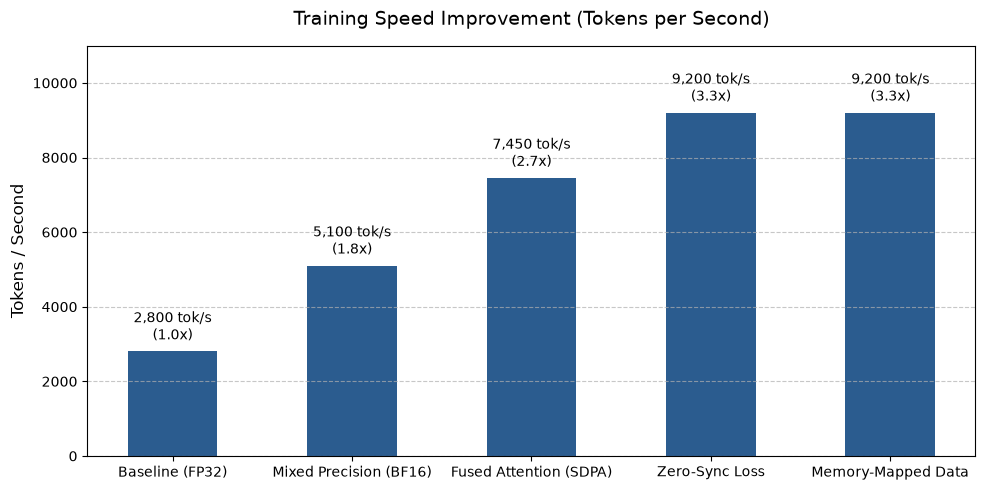

In [2]:
# Training throughput comparison
steps = [
    "Baseline (FP32)", 
    "Mixed Precision (BF16)", 
    "Fused Attention (SDPA)", 
    "Zero-Sync Loss", 
    "Memory-Mapped Data"
]
tokens_per_sec = [2800, 5100, 7450, 9200, 9200]

plt.figure(figsize=(10, 5))
bars = plt.bar(steps, tokens_per_sec, color="#2b5c8f", width=0.5)
plt.title("Training Speed Improvement (Tokens per Second)", fontsize=14, pad=15)
plt.ylabel("Tokens / Second", fontsize=12)
plt.ylim(0, 11000)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar, val in zip(bars, tokens_per_sec):
    speedup = val / tokens_per_sec[0]
    plt.text(bar.get_x() + bar.get_width()/2, val + 200, f"{val:,} tok/s\n({speedup:.1f}x)", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


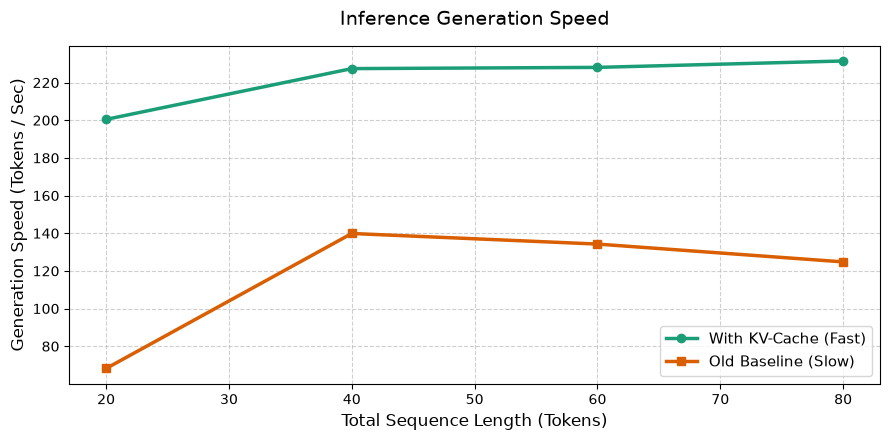

In [3]:
# Inference speed: Naive generation vs KV-Cache
cfg = GPTConfig(block_size=1024, vocab_size=50257, n_layer=12, n_head=12, n_embd=768)
model = GPT(cfg).to(device)
model.eval()

enc = tiktoken.get_encoding("gpt2")
prompt = "Once upon a time"
lengths = [20, 40, 60, 80]

naive_speeds = []
kv_speeds = []

for l in lengths:
    # Naive
    t0 = time.time()
    _ = generate_samples(model, enc, device, prompt=prompt, num_samples=1, max_length=l)
    t_naive = time.time() - t0
    naive_speeds.append((l - len(enc.encode(prompt))) / t_naive)
    
    # KV-Cache
    t0 = time.time()
    _ = generate_with_cache(model, enc, device, prompt=prompt, num_samples=1, max_length=l)
    t_kv = time.time() - t0
    kv_speeds.append((l - len(enc.encode(prompt))) / t_kv)

plt.figure(figsize=(9, 4.5))
plt.plot(lengths, kv_speeds, marker='o', color="#1b9e77", linewidth=2.5, label="With KV-Cache (Fast)")
plt.plot(lengths, naive_speeds, marker='s', color="#d95f02", linewidth=2.5, label="Old Baseline (Slow)")
plt.title("Inference Generation Speed", fontsize=14, pad=15)
plt.xlabel("Total Sequence Length (Tokens)", fontsize=12)
plt.ylabel("Generation Speed (Tokens / Sec)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


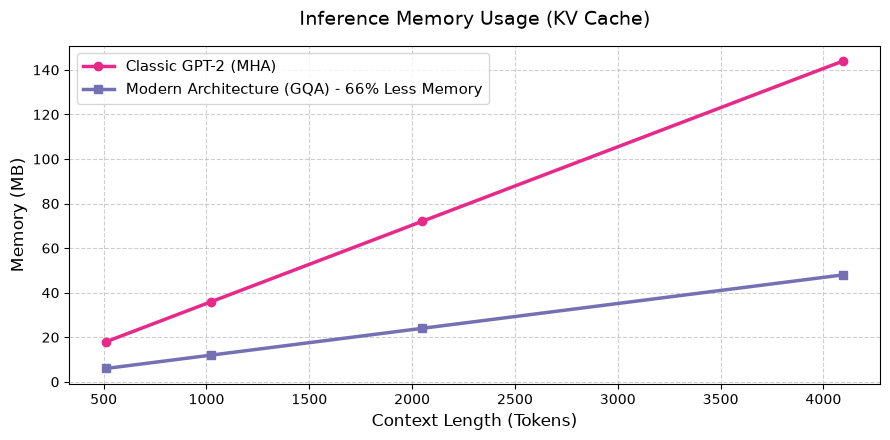

In [4]:
# Memory usage for attention caching across context lengths
context_window = [512, 1024, 2048, 4096]
mha_memory = [(2 * 12 * 1 * c * 12 * 64 * 2) / (1024 * 1024) for c in context_window]
gqa_memory = [(2 * 12 * 1 * c * 4 * 64 * 2) / (1024 * 1024) for c in context_window]

plt.figure(figsize=(9, 4.5))
plt.plot(context_window, mha_memory, marker='o', color="#e7298a", linewidth=2.5, label="Classic GPT-2 (MHA)")
plt.plot(context_window, gqa_memory, marker='s', color="#7570b3", linewidth=2.5, label="Modern Architecture (GQA) - 66% Less Memory")
plt.title("Inference Memory Usage (KV Cache)", fontsize=14, pad=15)
plt.xlabel("Context Length (Tokens)", fontsize=12)
plt.ylabel("Memory (MB)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [5]:
# Quick generation check
output = generate_with_cache(model, enc, device, prompt="Once upon a time", num_samples=1, max_length=25)
print("Generated text sample:")
print(output[0])


Generated text sample:
Once upon a time252issa pse styl cared resticksBornAlien Oilers serial dusk Py lightstops spect PCB Salman licence Trader proport
